In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
a = 1.0       # Коэффициент теплопроводности
B = 1.0       # Коэффициент в начальном условии
L = 1.0       # Длина стержня
T = 0.1 

In [4]:
def numerical_heat_solution():
    # Параметры сетки
    Nx = 100      # Количество узлов по пространству
    Nt = 1000     # Количество узлов по времени
    dx = L / (Nx - 1)
    dt = T / (Nt - 1)
    
    r = (a**2) * dt / (dx**2)
    if r > 0.5:
        print(f"Внимание: схема может быть неустойчива (r = {r:.2f} > 0.5)")
    
    # Создание сетки
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    U = np.zeros((Nx, Nt))
    
    # Начальное условие: U(x, 0) = B*x^3
    U[:, 0] = B * x**3
    
    # Численное решение (явная схема)
    for j in range(0, Nt - 1):
        for i in range(1, Nx - 1):
            U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
        
        # Граничное условие на правом конце
        U[-1, j + 1] = (4 * U[-2, j + 1] - U[-3, j + 1]) / 3
    
    return x, t, U

In [6]:
def solve_analytical_ode():
    # Преобразование переменных: z = x/sqrt(t), f(z) = U(x,t)/(B*x^3)
    # Ваше ОДУ: f''(z) + f'(z)*(6/z + z/2) + (6/z^2)*f(z) = 0
    
    def ode_system(z, y):
        f, df = y
        ddf = -df*(6/z + z/2) - (6/z**2)*f
        return [df, ddf]
    
    # Начальные условия (нужно подобрать правильно!)
    # Это сложная часть, так как при z->0 уравнение имеет особенность
    # Возможно, нужно использовать асимптотическое разложение при малых z
    z_span = [1e-3, 10]  # Избегаем z=0 из-за особенности
    z_eval = np.linspace(z_span[0], z_span[1], 100)
    
    # Пробные начальные условия (возможно, потребуется подгонка)
    f0 = 1.0    # f(z0)
    df0 = 0.0    # f'(z0)
    
    sol = solve_ivp(ode_system, z_span, [f0, df0], t_eval=z_eval, method='LSODA')
    
    return sol.t, sol.y[0]

In [7]:
x_num, t_num, U_num = numerical_heat_solution()
z_anal, f_anal = solve_analytical_ode()


Внимание: схема может быть неустойчива (r = 0.98 > 0.5)


D:\Users\Boris\AppData\Local\Temp\ipykernel_16168\3489321972.py:23: RuntimeWarning: overflow encountered in scalar add
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
D:\Users\Boris\AppData\Local\Temp\ipykernel_16168\3489321972.py:23: RuntimeWarning: overflow encountered in scalar subtract
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
D:\Users\Boris\AppData\Local\Temp\ipykernel_16168\3489321972.py:23: RuntimeWarning: overflow encountered in scalar multiply
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
D:\Users\Boris\AppData\Local\Temp\ipykernel_16168\3489321972.py:23: RuntimeWarning: invalid value encountered in scalar add
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])


In [8]:
t_idx = -1
selected_time = t_num[t_idx]


In [9]:
z = x_num / np.sqrt(a**2 * selected_time)
# Интерполируем аналитическое решение на сетку z
from scipy.interpolate import interp1d
f_interp = interp1d(z_anal, f_anal, bounds_error=False, fill_value="extrapolate")
U_analytical = B * x_num**3 * f_interp(z)

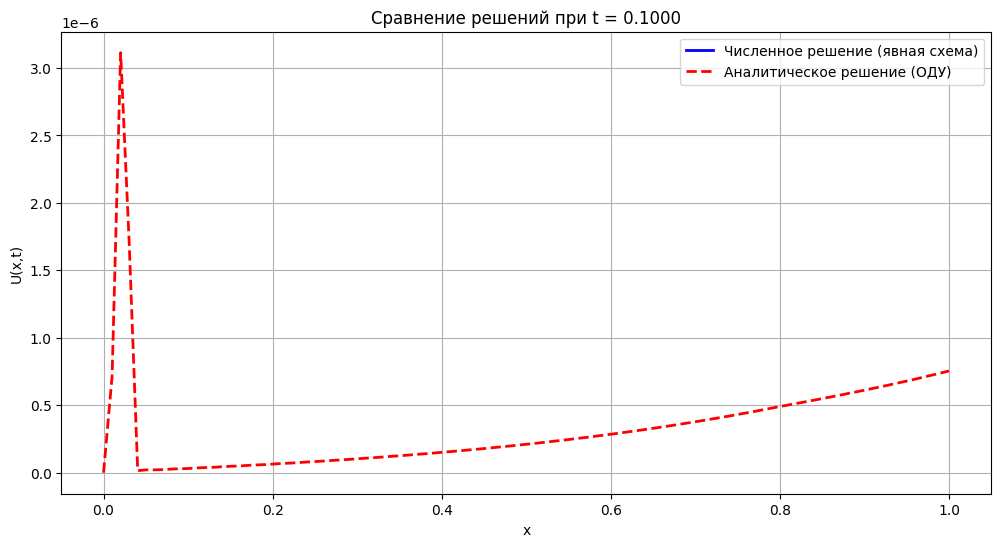

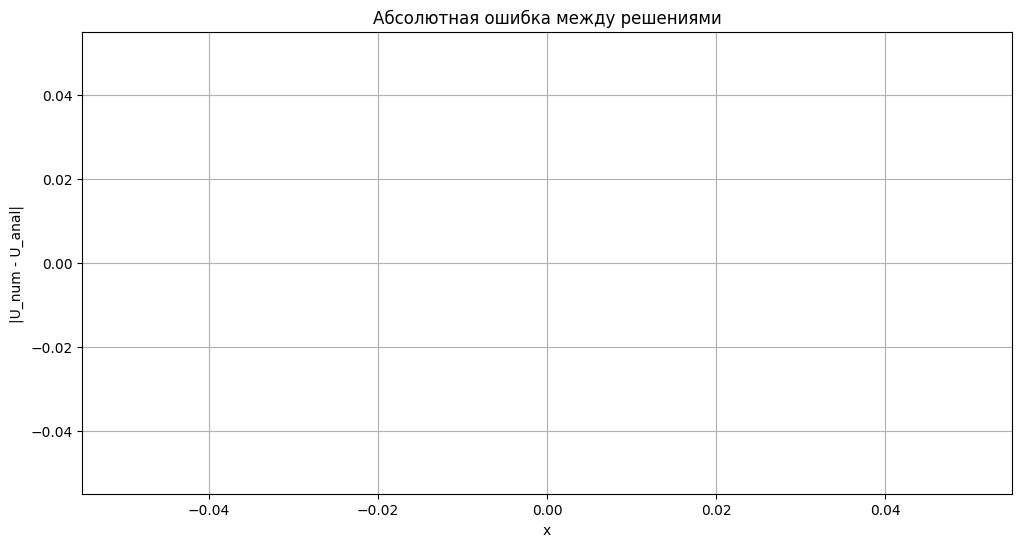

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(x_num, U_num[:, t_idx], 'b-', linewidth=2, label='Численное решение (явная схема)')
plt.plot(x_num, U_analytical, 'r--', linewidth=2, label='Аналитическое решение (ОДУ)')
plt.title(f'Сравнение решений при t = {selected_time:.4f}')
plt.xlabel('x')
plt.ylabel('U(x,t)')
plt.legend()
plt.grid(True)
plt.show()
error = np.abs(U_num[:, t_idx] - U_analytical)
plt.figure(figsize=(12, 6))
plt.plot(x_num, error, 'g-', linewidth=2)
plt.title('Абсолютная ошибка между решениями')
plt.xlabel('x')
plt.ylabel('|U_num - U_anal|')
plt.grid(True)
plt.show()